In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA

print("Loading MNIST...")

mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist.data / 255.0
y = mnist.target.astype(int)

# PCA إلى بعدين من أجل الرسم
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# تدريب النموذج على الرقم 0 فقط
X_train = X_pca[y == 0]

svm = OneClassSVM(kernel="rbf", gamma="auto", nu=0.05)

svm.fit(X_train)

# التنبؤ على جميع الأرقام
pred = svm.predict(X_pca)

print("Prediction values:")
print(np.unique(pred))

Loading MNIST...
Prediction values:
[-1  1]


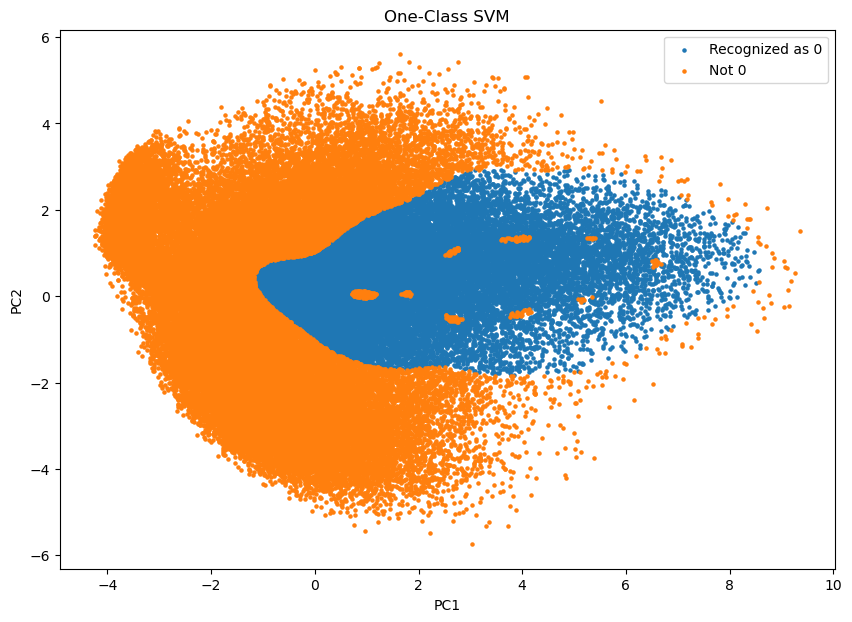

In [2]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[pred==1,0],
    X_pca[pred==1,1],
    s=5,
    label="Recognized as 0"
)

plt.scatter(
    X_pca[pred==-1,0],
    X_pca[pred==-1,1],
    s=5,
    label="Not 0"
)

plt.legend()

plt.title("One-Class SVM")

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()